# Downstream Exploitation of Space Data
## Session 7: Unsupervised Machine Learning

### Learning Objectives

You will: 
* know the type of problems unsupervised machine learning solves and see some examples
* be able to perform dimensionality reduction on a dataset
* be able to perform unsupervised clustering on a dataset
* get familiar with a learning problem of clustering variable stars

### Dimensionality Reduction

Dimensionality reduction is a learning problem in unsupervised learning that reduces the number of input features or variables in a dataset while retaining as much important information as possible.

Importing the libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [46]:
plt.rc('font',   size=16)          # controls default text sizes
plt.rc('axes',   titlesize=16)     # fontsize of the axes title
plt.rc('axes',   labelsize=16)     # fontsize of the x and y labels
plt.rc('xtick',  labelsize=14)     # fontsize of the tick labels
plt.rc('ytick',  labelsize=14)     # fontsize of the tick labels
plt.rc('legend', fontsize=16)      # legend fontsize
plt.rc('figure', titlesize=16)     # fontsize of the figure title

#### Toy Dataset

Creating a dataset with two correlated features:

In [47]:
np.random.seed(42)
n_samples = 100

In [48]:
x = np.random.rand(n_samples)
y = 0.8 * x + 0.2 * np.random.rand(n_samples)

In [49]:
data = pd.DataFrame({'Feature 1': x, 'Feature 2': y})

Standardizing the data:

In [50]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

Applying the PCA:

In [51]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

Let's visualize both our original and 'pca'ed' data: 

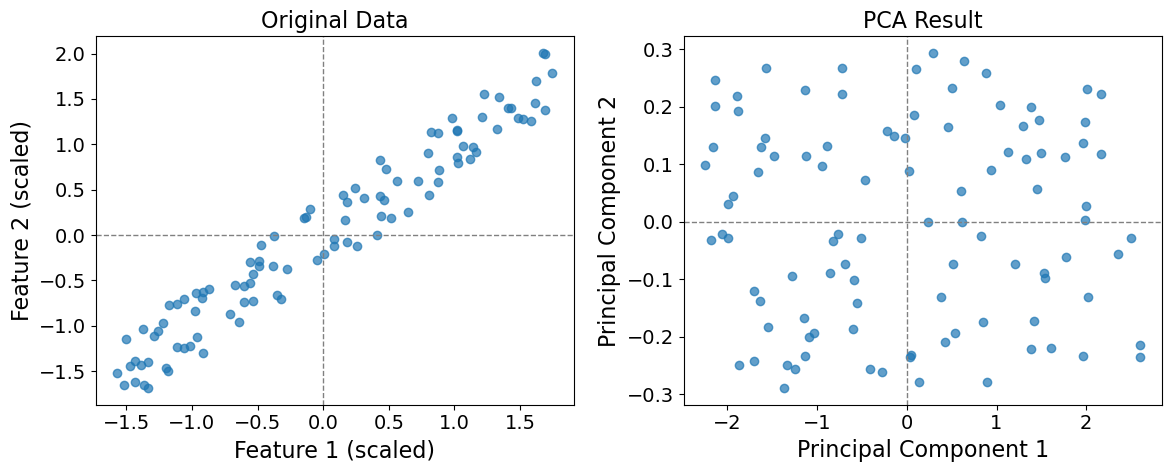

In [52]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # the original dataset
plt.scatter(scaled_data[:, 0], scaled_data[:, 1], alpha=0.7)
plt.title('Original Data')
plt.xlabel('Feature 1 (scaled)')
plt.ylabel('Feature 2 (scaled)')
plt.axhline(0, color='gray', linestyle='--', lw=1)
plt.axvline(0, color='gray', linestyle='--', lw=1)

plt.subplot(1, 2, 2) # the PCA-transformed dataset
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.7)
plt.title('PCA Result')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.axhline(0, color='gray', linestyle='--', lw=1)
plt.axvline(0, color='gray', linestyle='--', lw=1)

plt.tight_layout()
plt.show()

Let's see how much each of the components explains variance in the data:

In [53]:
explained_variance = pca.explained_variance_ratio_
print(f'Explained variance by component 1: {explained_variance[0]:.2f}')
print(f'Explained variance by component 2: {explained_variance[1]:.2f}')

Explained variance by component 1: 0.99
Explained variance by component 2: 0.01


**Discuss with your neighbour:** Which component explains more variance in the data?

We can also see the contribution of each feature of each component:

In [54]:
components_df = pd.DataFrame(pca.components_, 
                             columns=['Feature 1', 'Feature 2'], 
                             index=['Component 1', 'Component 2'])

print('\nFeature contributions to each principal component:')
print(components_df)


Feature contributions to each principal component:
             Feature 1  Feature 2
Component 1   0.707107   0.707107
Component 2   0.707107  -0.707107


**Discuss with your neighbour:** Why do you think the contributions in the second component are equal in magnitude but opposite in sign? (*Hint: think about how the PCA works.*)

### Clustering

#### Toy Dataset

In [55]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

Loading the iris dataset that we have seen before:

In [56]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

Standardizing the data:

In [57]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Let's now apply k-means clustering to our data:

In [58]:
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X_scaled)

4D data is difficult to visualize so we can rescale it to 2D with a dimensionality reduction method:

In [59]:
pca = PCA(n_components=2)
X_2D = pca.fit_transform(X_scaled)

In [60]:
centers_2D = pca.transform(kmeans.cluster_centers_)

Let's plot the data:

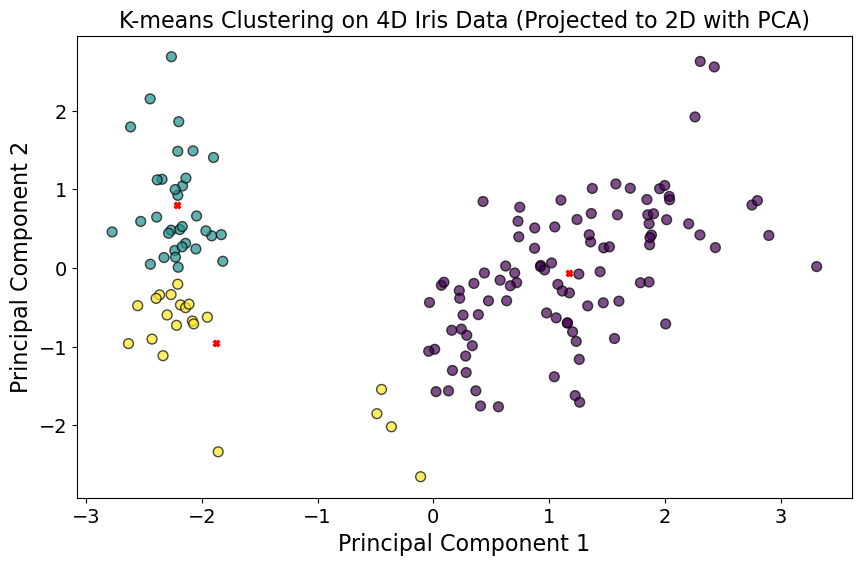

In [61]:
plt.figure(figsize=(10, 6))

plt.scatter(X_2D[:, 0], X_2D[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7, edgecolors='k')
plt.scatter(centers_2D[:, 0], centers_2D[:, 1], c='red', s=20, marker='X')

plt.title('K-means Clustering on 4D Iris Data (Projected to 2D with PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.show()

**Discuss with your neighbour:** Do you think clusters are well-separated? Note that here separate colors represent clusters assigned by our clustering algorithm, NOT the initial labels.

Given that we have true labels (NB: which is often not the case for unsupervised learning) we can compare our clustering with actual labels:

In [62]:
true_colors = plt.cm.Set1(y)
cluster_colors = plt.cm.Paired(labels)

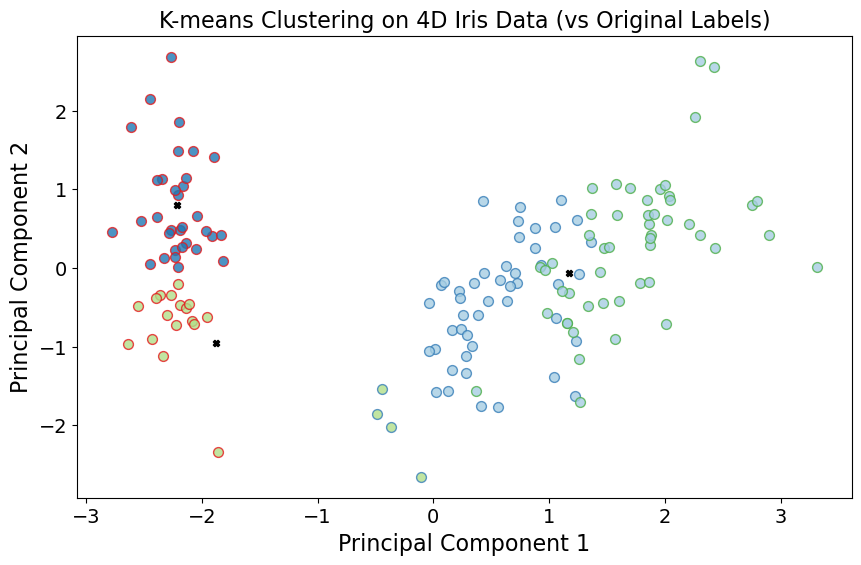

In [63]:
plt.figure(figsize=(10, 6))
for i in range(X_2D.shape[0]):
    plt.scatter(X_2D[i, 0], X_2D[i, 1], 
                color=cluster_colors[i], 
                edgecolors=true_colors[i],
                s=50, alpha=0.8, linewidth=1)

plt.scatter(centers_2D[:, 0], centers_2D[:, 1], 
            c='black', s=20, marker='X')

plt.title('K-means Clustering on 4D Iris Data (vs Original Labels)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.show()

**Discuss with your neighbour:** What do you think now?

We can also evaluate clustering quality:

In [64]:
silhouette = silhouette_score(X_scaled, labels)
print(f'Silhouette Score: {silhouette:.2f}')

Silhouette Score: 0.48


**Discuss with your neighbour:** How would you evaluate the performance of this clustering as a whole?

#### Variable Star Dataset

In [65]:
pip install umap-learn

Note: you may need to restart the kernel to use updated packages.


In [66]:
import umap.umap_ as umap
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

Let's load the dataset from the previous session again:

In [67]:
df = pd.read_csv('supervised.csv')
df.head()

,Unnamed: 0,TIC,Sector,Class,Amplitude,AndersonDarling,Autocor_length,Con,Eta_e,FluxPercentileRatioMid20,...,Psi_CS,Psi_eta,Q31,Rcs,Skew,SmallKurtosis,Std,StructureFunction_index_21,StructureFunction_index_31,StructureFunction_index_32
0,0,121788685,40,gdor_spb,0.012499,1.000000,12.0,0.003059,0.049083,0.241412,...,0.210949,0.308100,0.012968,0.025453,0.253529,-1.105627,0.007477,1.805659,2.404854,1.358320
1,1,159107517,40,contact_rot,0.001117,0.972301,12.0,0.007137,0.659307,0.148367,...,0.098484,1.898308,0.000744,0.042147,-0.096938,0.355266,0.000567,2.072192,3.199932,1.570209
2,2,164409716,40,dsct_bcep,0.010492,0.846461,1.0,0.000255,2.111645,0.160205,...,0.048566,1.907580,0.007418,0.017033,0.048196,0.076288,0.005468,2.016101,3.074184,1.598993
3,3,273043307,41,eclipse,0.273848,1.000000,22.0,0.052919,0.010379,0.017463,...,0.270511,1.489218,0.037857,0.039258,-3.038883,9.956646,0.109472,2.112600,3.311446,1.598922
4,4,159716883,40,gdor_spb,0.009554,1.000000,17.0,0.011726,0.636592,0.140787,...,0.126239,1.904594,0.006247,0.029084,-0.113706,1.063223,0.004870,1.962611,2.935181,1.530732


We drop all non-feature columns:

In [68]:
X = df.drop(columns=['Unnamed: 0', 'TIC', 'Sector', 'Class'])

Then we standardize the data and apply clustering:

In [69]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.values.astype(np.float32))

In [70]:
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X_scaled)

We have a multi-dimensional space that is impossible to visualise so we use another dimensionality reduction technique, UMAP:

In [71]:
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

/home/mykytak/.conda/envs/putess/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Let's now plot the clusters: 

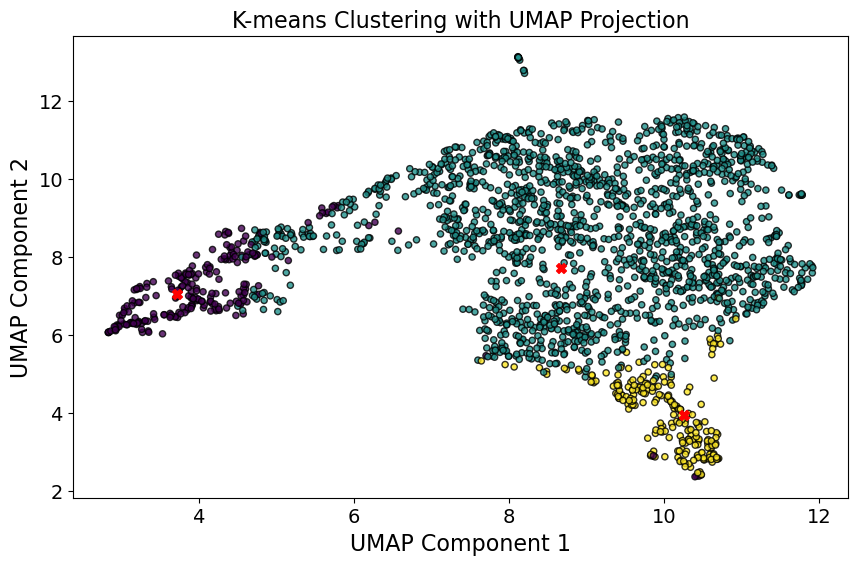

In [72]:
plt.figure(figsize=(10, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=labels, cmap='viridis', s=20, alpha=0.8, edgecolors='k')
plt.title('K-means Clustering with UMAP Projection')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')

centers_umap = reducer.transform(kmeans.cluster_centers_)
plt.scatter(centers_umap[:, 0], centers_umap[:, 1], c='red', s=50, marker='X')

plt.show()

Let's see how it corresponds to true labels:

In [73]:
y = df['Class']

In [74]:
cluster_cmap = ListedColormap(plt.cm.viridis(np.linspace(0, 1, n_clusters)))
true_cmap = ListedColormap(plt.cm.inferno(np.linspace(0, 1, len(np.unique(y)))))

In [75]:
cluster_colors = cluster_cmap(labels)
true_colors = true_cmap(pd.factorize(y)[0])

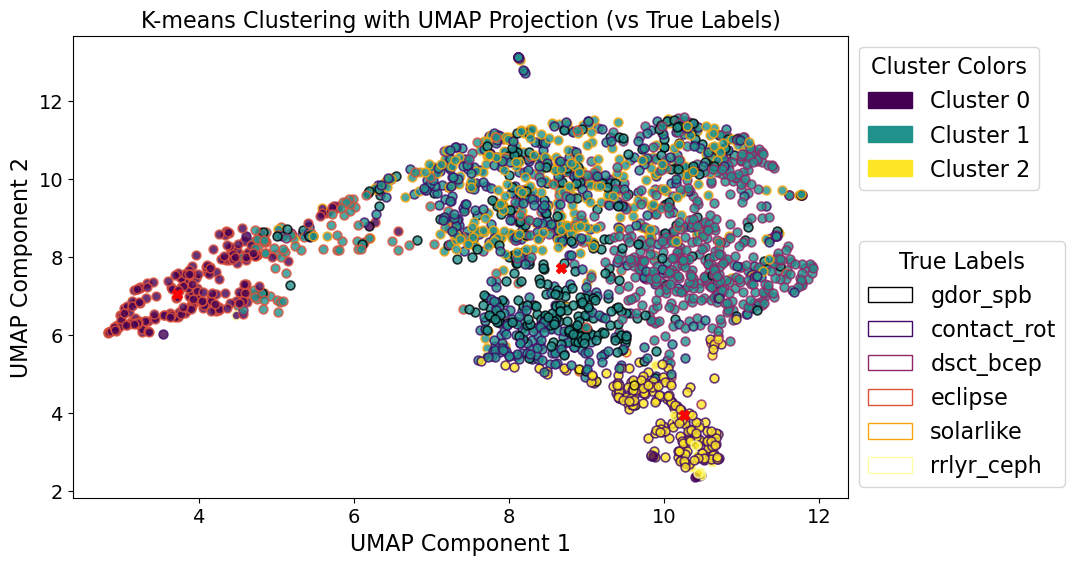

In [76]:
plt.figure(figsize=(10, 6))

for i in range(X_umap.shape[0]):
    plt.scatter(X_umap[i, 0], X_umap[i, 1], 
                color=cluster_colors[i], 
                edgecolors=true_colors[i],
                s=40, alpha=0.8, linewidth=1.2)

centers_umap = reducer.transform(kmeans.cluster_centers_)
plt.scatter(centers_umap[:, 0], centers_umap[:, 1], 
            c='red', s=50, marker='X')

cluster_handles = [mpatches.Patch(color=cluster_cmap(i / (n_clusters - 1)), label=f'Cluster {i}')
                   for i in range(n_clusters)]

unique_labels, label_names = pd.factorize(y)
true_label_handles = [mpatches.Patch(edgecolor=true_cmap(i / (len(label_names) - 1)), 
                                     facecolor='white', label=label_names[i])
                      for i in range(len(label_names))]

legend1 = plt.legend(handles=cluster_handles, title='Cluster Colors', loc='upper left', bbox_to_anchor=(1, 1))
legend2 = plt.legend(handles=true_label_handles, title='True Labels', loc='lower left', bbox_to_anchor=(1, 0))
plt.gca().add_artist(legend1)

plt.title('K-means Clustering with UMAP Projection (vs True Labels)')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')

plt.show()

**Discuss with your neighbour:** Which class get's the cleanest cluster?

**To do:** Change the number of clusters and rerun the cells above. Observe what changes and think if it makes sence given your knowledge of the dataset.

In [77]:
silhouette = silhouette_score(X_scaled, labels)
print(f'Silhouette Score: {silhouette:.2f}')

Silhouette Score: 0.30


**Discuss with your neighbour:** How would you evaluate the performance of this clustering as a whole?

Let's now try to plot the result of clustering with different numbers of clusters side-by-side:

In [78]:
clusters = [2, 3, 4] # change this into how many clusters you want!

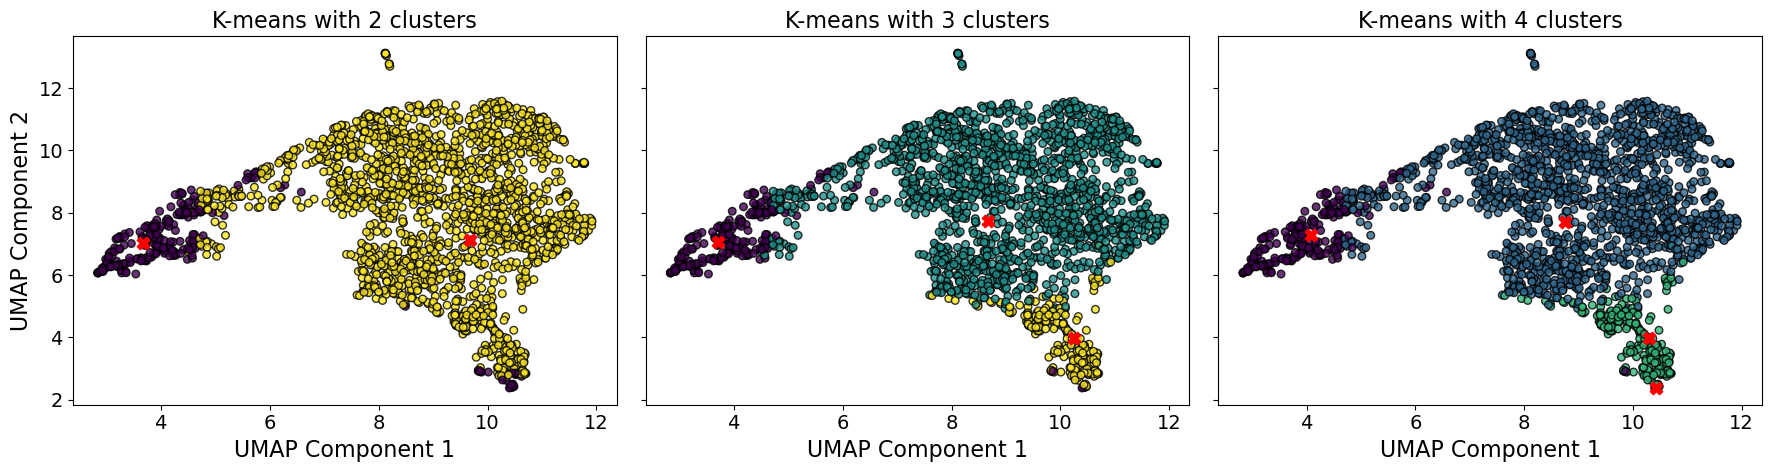

In [79]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

for i, n_clusters in enumerate(clusters):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_scaled)
    
    axes[i].scatter(X_umap[:, 0], X_umap[:, 1], c=labels, cmap='viridis', s=30, alpha=0.8, edgecolors='k')
    
    centers_umap = reducer.transform(kmeans.cluster_centers_)
    axes[i].scatter(centers_umap[:, 0], centers_umap[:, 1], c='red', s=80, marker='X')

    axes[i].set_title(f'K-means with {n_clusters} clusters')
    axes[i].set_xlabel('UMAP Component 1')
    if i == 0:
        axes[i].set_ylabel('UMAP Component 2')

plt.tight_layout()
plt.show()

**To do (for the report):** Change the three numbers in the clusters list to produce a plot with three clusterings (please **do not** use [2,3,4] for your report!) and discuss different clustering results in your report. **This figure needs to be improved** before you put it in your report: you need to add legend, fix label sizes, etc. (demonstrate what you can do to make it presentable and make sure the point you are trying to make is clearly visible).

*NB:* you do not need to show real classes (and you would normally not be able to do that when working with clustering) but feel free to do that if you want to discuss this for your report. If you do, it might be helpful to read the description of classes in the Audenaert at al (2021) paper and look at the statistical distribution of features (as you did for session 6) but this is not compulsory. These additional plots are not required but feel free to include them if they support your point.